In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset (using your local path)
df = pd.read_csv('../data/CaliforniaHousing.csv')

# First 5 records
display(df.head())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,5.3668,27.0,6.702899,1.028986,1793.0,3.248188,33.92,-117.98,2.198
1,3.4919,44.0,5.138418,1.031073,1137.0,3.211864,37.75,-122.50,2.718
2,1.6196,38.0,3.830116,1.077220,732.0,2.826255,37.75,-122.17,0.851
3,4.0926,42.0,4.525114,0.981735,717.0,3.273973,33.89,-118.09,1.644
4,3.9063,41.0,4.633540,0.900621,387.0,2.403727,37.69,-122.10,1.784


In [2]:
# Last 5 records
display(df.tail())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
95,4.1050,16.0,6.035963,1.041763,2515.0,2.917633,32.83,-116.91,1.744
96,6.6073,17.0,6.771499,0.939803,2734.0,3.358722,34.29,-118.75,2.581
97,5.0758,35.0,6.378000,1.054000,1727.0,3.454000,34.05,-117.91,2.111
98,5.5061,17.0,6.923129,1.134862,4956.0,3.341875,34.46,-118.50,2.394
99,2.5313,30.0,5.039384,1.193493,NaN,2.679795,35.14,NaN,0.458


In [3]:
# Shape of the dataset
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (100, 9)


In [4]:
# Column names
print(f"Column Names:\n{df.columns.tolist()}")


Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseValue']


In [5]:
num_samples = df.shape[0]
num_features = df.shape[1] - 1 # Assuming 1 target variable

print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features} (excluding target)")


Number of samples: 100
Number of features: 8 (excluding target)


In [6]:
num_samples = df.shape[0]
num_features = df.shape[1] - 1 # Assuming 1 target variable

print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features} (excluding target)")


Number of samples: 100
Number of features: 8 (excluding target)


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         100 non-null    float64
 1   HouseAge       100 non-null    float64
 2   AveRooms       99 non-null     float64
 3   AveBedrms      100 non-null    float64
 4   Population     97 non-null     float64
 5   AveOccup       99 non-null     float64
 6   Latitude       99 non-null     float64
 7   Longitude      96 non-null     float64
 8   MedHouseValue  100 non-null    float64
dtypes: float64(9)
memory usage: 7.2 KB


In [8]:
# Display statistical summary
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,100.000000,100.000000,99.000000,100.000000,97.000000,99.000000,99.000000,96.000000,100.000000
mean,3.658175,28.860000,5.102687,1.048504,1526.123711,3.036994,35.560101,-119.535938,1.969290
std,1.441273,11.658456,1.155867,0.117671,1055.858865,0.648765,2.187016,2.030024,1.069005
min,1.225400,4.000000,2.096692,0.877301,240.000000,1.360332,32.710000,-124.130000,0.458000
25%,2.626625,18.000000,4.236945,1.006378,785.000000,2.633496,33.930000,-121.585000,1.327000
50%,3.491900,29.000000,5.152500,1.030534,1263.000000,2.935368,34.250000,-118.545000,1.659000
75%,4.406250,37.000000,5.912333,1.077766,1959.000000,3.350298,37.550000,-118.010000,2.541000
max,8.113200,52.000000,8.970968,1.990323,5587.000000,4.856655,40.920000,-116.910000,5.000010


In [9]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate records
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {num_duplicates}")

# Remove duplicates if any exist
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Updated Dataset Shape after removing duplicates: {df.shape}")


Missing values per column:
MedInc           0
HouseAge         0
AveRooms         1
AveBedrms        0
Population       3
AveOccup         1
Latitude         1
Longitude        4
MedHouseValue    0
dtype: int64

Number of duplicate records: 4
Updated Dataset Shape after removing duplicates: (96, 9)


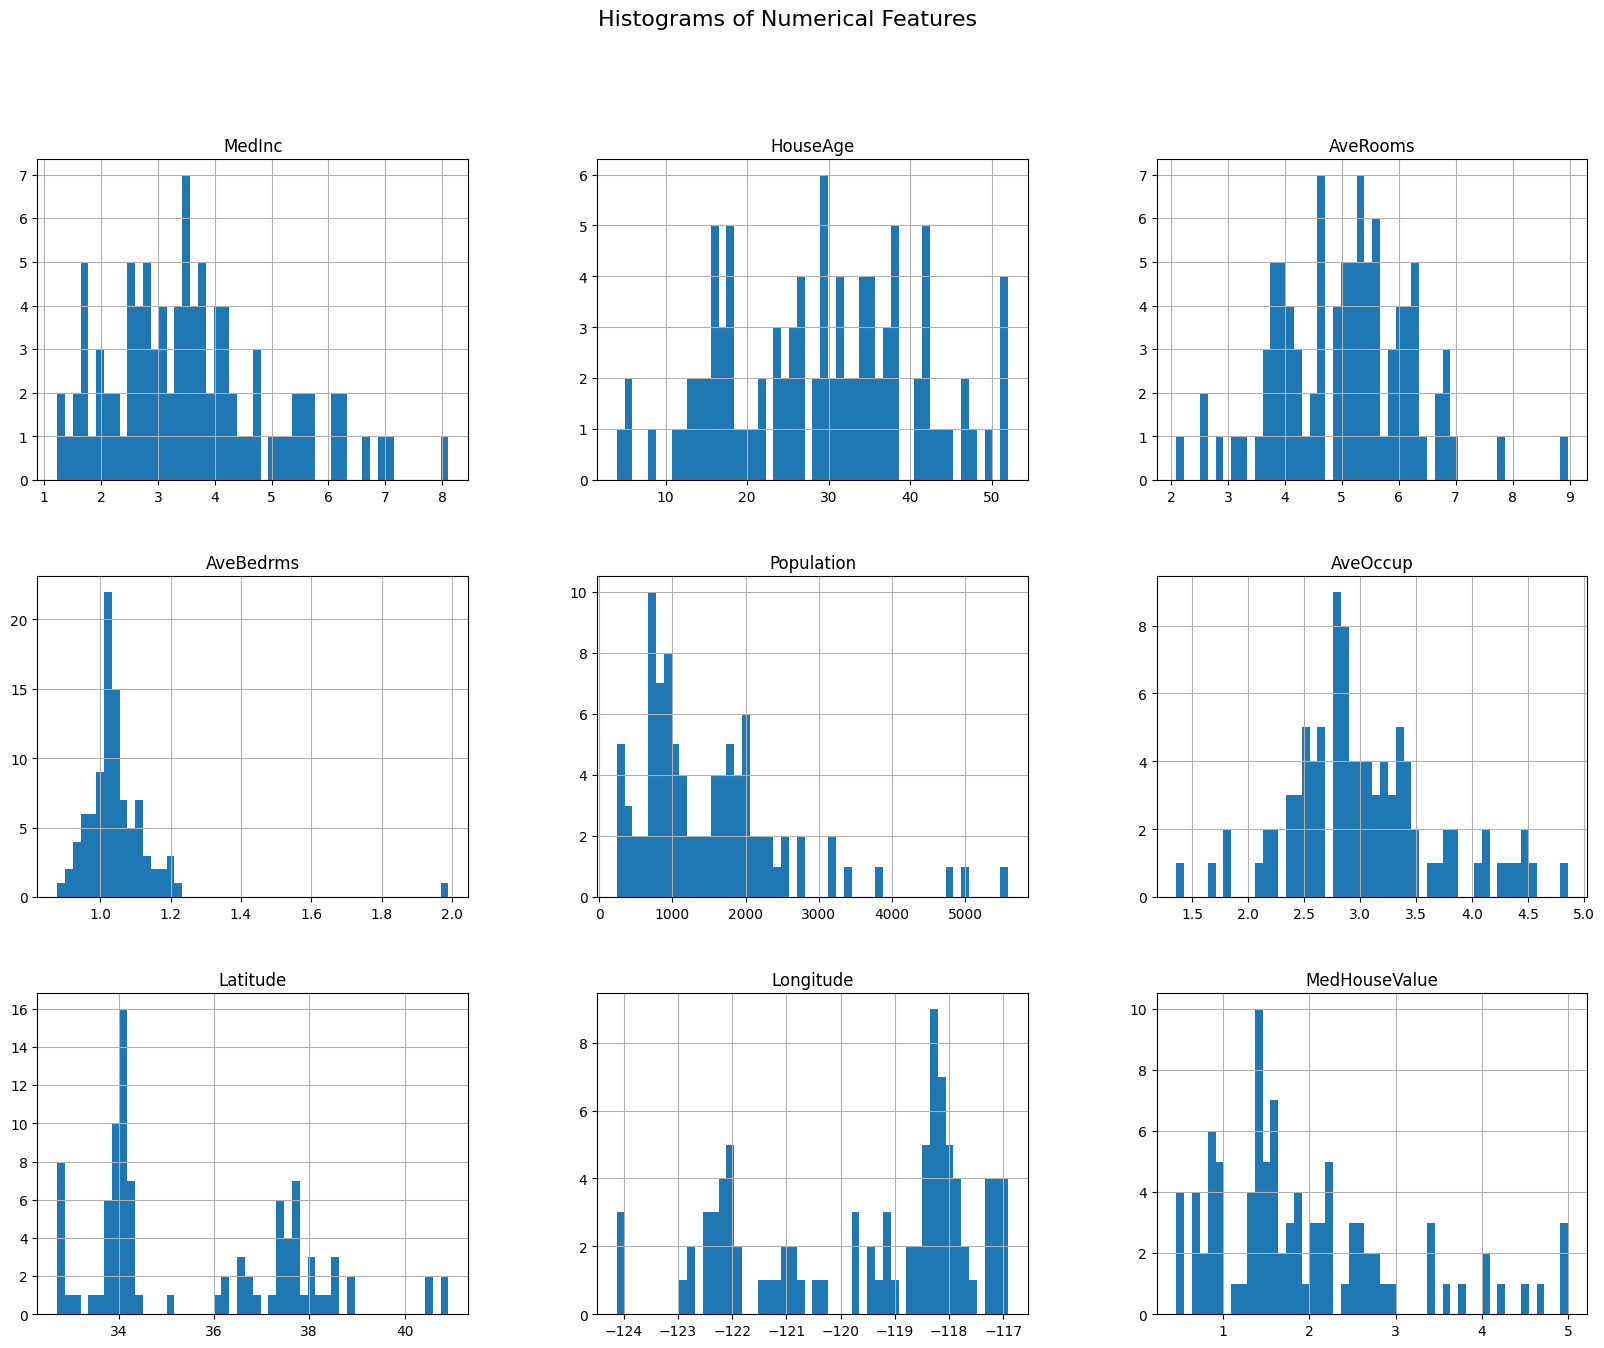

In [10]:
# Generate histograms for all numerical features
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()


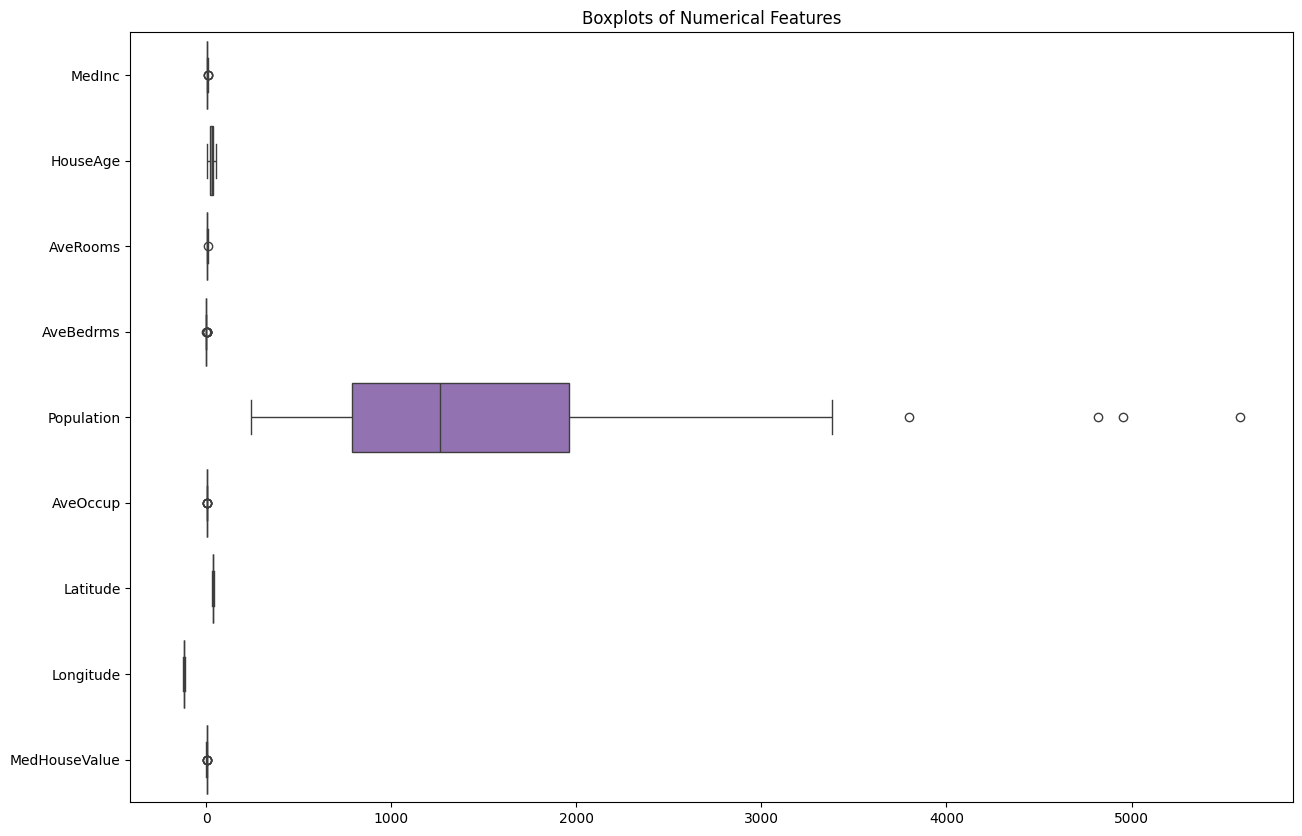

In [11]:
# Generate boxplots for numerical features
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=[np.number]), orient="h")
plt.title('Boxplots of Numerical Features')
plt.show()


In [12]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.1)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income (tens of thousands of $)')
plt.ylabel('Median House Value ($)')
plt.show()


ValueError: Could not interpret value `median_income` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>